In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

# Read files
train_data = pd.read_csv('../titanic/train.csv')
test_data = pd.read_csv('../titanic/test.csv')
gender_submission_data = pd.read_csv('../titanic/gender_submission.csv')

In [10]:
# Remove columns that are not needed for the model
train_data_clean = train_data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
test_data_clean = test_data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Handle missing values
train_data_clean['Age'] = train_data_clean['Age'].fillna(train_data_clean['Age'].median())
train_data_clean['Embarked'] = train_data_clean['Embarked'].fillna(train_data_clean['Embarked'].mode()[0])
test_data_clean['Age'] = test_data_clean['Age'].fillna(test_data_clean['Age'].median())
test_data_clean['Fare'] = test_data_clean['Fare'].fillna(test_data_clean['Fare'].median())

# Combine train and test sets to encode categorical variables
combined_data = pd.concat([train_data_clean, test_data_clean], axis=0, ignore_index=True)

# Convert categorical variables to numeric values
label_encoder = LabelEncoder()
combined_data['Sex'] = label_encoder.fit_transform(combined_data['Sex'])
combined_data['Embarked'] = label_encoder.fit_transform(combined_data['Embarked'])

# Split back into train and test sets
train_data_clean = combined_data[:len(train_data_clean)]
test_data_clean = combined_data[len(train_data_clean):]

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(train_data_clean.drop(columns=['Survived']))
y_train = train_data_clean['Survived']
X_test = scaler.transform(test_data_clean.drop(columns=['Survived']))

In [11]:
# Train the neural network
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# Predictions on the test set
y_pred = mlp.predict(X_test)

# Convert predictions to int type
y_pred = y_pred.astype(int)

# Compare with actual answers
real_y = gender_submission_data['Survived']
accuracy = accuracy_score(real_y, y_pred)

# Error metrics
mse = mean_squared_error(real_y, y_pred)
mae = mean_absolute_error(real_y, y_pred)
rmse = np.sqrt(mse)

In [12]:
# Print metrics
print(f"Average model accuracy: {accuracy * 100:.2f}%")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Average model accuracy: 90.43%
MSE: 0.0957
MAE: 0.0957
RMSE: 0.3093


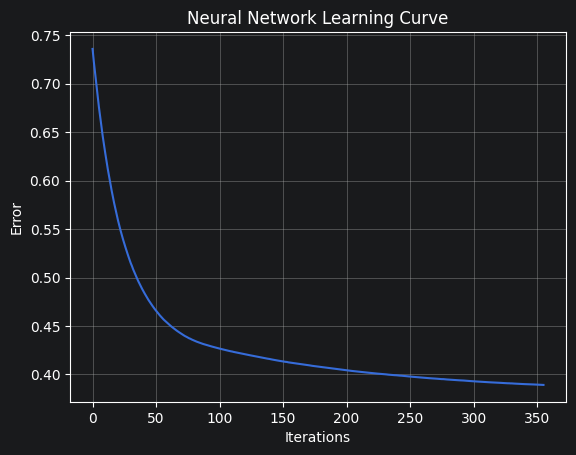

In [13]:
# Visualize the training process
plt.plot(mlp.loss_curve_)
plt.title('Neural Network Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.grid(True)
plt.show()

In [14]:
# Write predictions to the "submission.csv" file
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': y_pred
})
submission.to_csv('submission.csv', index=False)

In [15]:
# Print the first 10 predictions and actual values
pred_vs_real = pd.DataFrame({
    'Predicted': y_pred[:10],
    'Real': real_y[:10]
})

print("First 10 predictions and actual values:")
print(pred_vs_real)

First 10 predictions and actual values:
   Predicted  Real
0          0     0
1          0     1
2          0     0
3          0     0
4          0     1
5          0     0
6          1     1
7          0     0
8          1     1
9          0     0
